# LLM Precision Benchmark: FP32 vs FP16 vs INT4 on NVIDIA T4

## Overview
This notebook benchmarks the same LLM (facebook/opt-125m) loaded in three
different numeric precisions — FP32, FP16, and INT4 — on a free Google Colab
NVIDIA T4 GPU.

## What We Measure
- **GPU Memory Usage (MB)** — how much VRAM each precision consumes
- **Inference Speed (tokens/sec)** — how fast each precision generates text
- **Output Quality** — whether reducing precision changes the model's responses

## Key Findings
- FP16 is the clear winner on T4: 2× less memory than FP32, 2.3× faster, identical output quality
- INT4 uses the least memory (4× smaller than FP32) but is not faster on T4
- INT4 underperforms on T4 because the GPU must decompress INT4 → FP16 at runtime,
  adding overhead. Newer GPUs (A100, H100) handle INT4 natively and don't have this problem.

## Stack
- Python, PyTorch, HuggingFace Transformers, bitsandbytes, matplotlib
- Hardware: NVIDIA T4 (Google Colab free tier)


In [1]:
!nvidia-smi

Thu Jun 11 04:41:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install transformers accelerate bitsandbytes -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.9 MB/s eta 0:00:00


In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_id = "facebook/opt-125m"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Load model in FP32 (default, no changes)
model_fp32 = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float32,
    device_map="cuda"
)

# Check memory used
mem = torch.cuda.memory_allocated() / 1024**2
print(f"FP32 model loaded!")
print(f"GPU memory used: {mem:.1f} MB")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/251M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

FP32 model loaded!
GPU memory used: 477.8 MB


In [4]:
# Clear the previous model from GPU memory first
del model_fp32
torch.cuda.empty_cache()

# Load same model in FP16
model_fp16 = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    device_map="cuda"
)

mem = torch.cuda.memory_allocated() / 1024**2
print(f"FP16 model loaded!")
print(f"GPU memory used: {mem:.1f} MB")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

FP16 model loaded!
GPU memory used: 242.3 MB


In [5]:
from transformers import BitsAndBytesConfig

# Clear previous model
del model_fp16
torch.cuda.empty_cache()

# INT4 config
quantization_config = BitsAndBytesConfig(load_in_4bit=True)

# Load same model in INT4
model_int4 = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="cuda"
)

mem = torch.cuda.memory_allocated() / 1024**2
print(f"INT4 model loaded!")
print(f"GPU memory used: {mem:.1f} MB")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INT4 model loaded!
GPU memory used: 122.8 MB


In [6]:
prompt = "Artificial intelligence is transforming the world by"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    output = model_int4.generate(**inputs, max_new_tokens=40)

print(tokenizer.decode(output[0], skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Artificial intelligence is transforming the world by making it easier for people to get vaccinated
Artificial intelligence is transforming the world by making it easier for people to get vaccinated.
The world's largest vaccine maker, Pfizer Inc., announced that


In [7]:
# Reload FP32
del model_int4
torch.cuda.empty_cache()

model_fp32 = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float32,
    device_map="cuda"
)

with torch.no_grad():
    output = model_fp32.generate(**inputs, max_new_tokens=40)

print("FP32 output:")
print(tokenizer.decode(output[0], skip_special_tokens=True))

# Now FP16
del model_fp32
torch.cuda.empty_cache()

model_fp16 = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    device_map="cuda"
)

with torch.no_grad():
    output = model_fp16.generate(**inputs, max_new_tokens=40)

print("\nFP16 output:")
print(tokenizer.decode(output[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

FP32 output:
Artificial intelligence is transforming the world by creating new ways to solve problems.

The world is changing, and artificial intelligence is transforming the world.

Artificial intelligence is transforming the world by creating new ways to solve problems.



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]


FP16 output:
Artificial intelligence is transforming the world by creating new ways to solve problems.

The world is changing, and artificial intelligence is transforming the world.

Artificial intelligence is transforming the world by creating new ways to solve problems.



In [8]:
import time

def measure_speed(model, tokenizer, prompt, max_new_tokens=40):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # Warm up run (GPU needs one run to "wake up" properly)
    with torch.no_grad():
        model.generate(**inputs, max_new_tokens=10)

    # Actual timed run
    torch.cuda.synchronize()  # Wait for GPU to finish
    start = time.time()

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens)

    torch.cuda.synchronize()  # Wait for GPU to finish
    end = time.time()

    elapsed = end - start
    tokens_per_sec = max_new_tokens / elapsed
    return round(tokens_per_sec, 2), round(elapsed, 3)

prompt = "Artificial intelligence is transforming the world by"

# FP16 is already loaded, measure it first
fp16_tps, fp16_time = measure_speed(model_fp16, tokenizer, prompt)
print(f"FP16 → {fp16_tps} tokens/sec ({fp16_time}s)")

# Load INT4 and measure
del model_fp16
torch.cuda.empty_cache()

model_int4 = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=BitsAndBytesConfig(load_in_4bit=True),
    device_map="cuda"
)
int4_tps, int4_time = measure_speed(model_int4, tokenizer, prompt)
print(f"INT4 → {int4_tps} tokens/sec ({int4_time}s)")

# Load FP32 and measure
del model_int4
torch.cuda.empty_cache()

model_fp32 = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float32,
    device_map="cuda"
)
fp32_tps, fp32_time = measure_speed(model_fp32, tokenizer, prompt)
print(f"FP32 → {fp32_tps} tokens/sec ({fp32_time}s)")

FP16 → 47.84 tokens/sec (0.836s)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INT4 → 20.97 tokens/sec (1.908s)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

FP32 → 21.06 tokens/sec (1.899s)


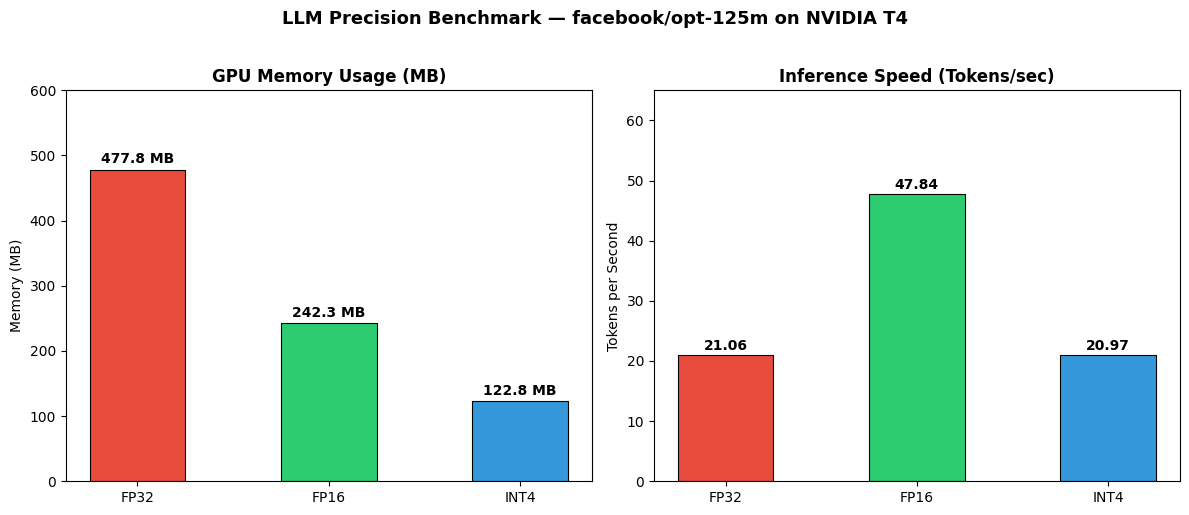

Chart saved as benchmark_results.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Your actual results
precisions = ['FP32', 'FP16', 'INT4']
memory = [477.8, 242.3, 122.8]
speed = [21.06, 47.84, 20.97]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('LLM Precision Benchmark — facebook/opt-125m on NVIDIA T4',
             fontsize=13, fontweight='bold', y=1.02)

colors = ['#e74c3c', '#2ecc71', '#3498db']

# Memory chart
bars1 = ax1.bar(precisions, memory, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
ax1.set_title('GPU Memory Usage (MB)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Memory (MB)')
ax1.set_ylim(0, 600)
for bar, val in zip(bars1, memory):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val} MB', ha='center', fontweight='bold')

# Speed chart
bars2 = ax2.bar(precisions, speed, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
ax2.set_title('Inference Speed (Tokens/sec)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tokens per Second')
ax2.set_ylim(0, 65)
for bar, val in zip(bars2, speed):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
             f'{val}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as benchmark_results.png")